## Implement KNN & SVM Algorithm & Evaluate Their Performance

In [4]:
## import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC

In [5]:
# load the iris dataset
iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(data=X, columns=iris.feature_names)
df['target'] = y
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [6]:
# Train - Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
# KNN Implementation
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("KNN Classification Report:\n", classification_report(y_test, y_pred_knn))

KNN Accuracy: 1.0
KNN Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
KNN Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [8]:
#SVM Implementation
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9666666666666667
SVM Confusion Matrix:
 [[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]
SVM Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



## Perform feature engineering Techniques such as encoding ,Scaling & feature Selection 
### encoding 
### Feature Scaling 
### Feature Selection

In [9]:
## import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.datasets import load_breast_cancer

In [10]:
# Load the Iris dataset
warnings.filterwarnings('ignore')
data = load_breast_cancer()
x= pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')


In [11]:
### encoding 
#### label encoding 
#df['gender'] = LabelEncoder().fit_transform
##### One-hot encoding
#df = pd.get_dummies(df, columns=['gender', 'job_type'] , drop_first=True)


In [12]:
# Feature Scaling 
scaling = StandardScaler()
x_scaled = scaling.fit_transform(x)

x_scaled_df = pd.DataFrame(x_scaled, columns=x.columns)

In [13]:
# Feature Selection 
#Method  : 1
selector = SelectKBest(score_func=f_classif, k=10)
x_new = selector.fit_transform(x_scaled_df, y)  
selected_features = x_scaled_df.columns[selector.get_support()]
print("Selected Features:\n", selected_features)

Selected Features:
 Index(['mean radius', 'mean perimeter', 'mean area', 'mean concavity',
       'mean concave points', 'worst radius', 'worst perimeter', 'worst area',
       'worst concavity', 'worst concave points'],
      dtype='object')


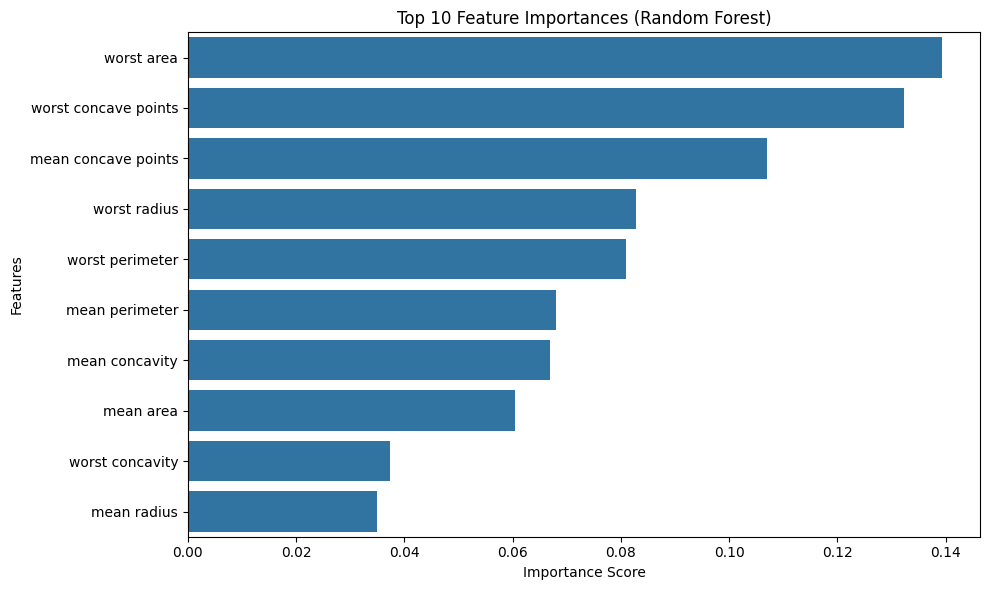

In [14]:
# method 2
# Method 2: Using Recursive Feature Elimination (Random Forest)
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_scaled_df, y)
importances = pd.Series(rf.feature_importances_, index=x_scaled_df.columns)
importances_sorted = importances.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances_sorted[:10], y=importances_sorted.index[:10])
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')  
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## Handle imbalanced datasets using appropriate techniques

In [15]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
%pip install imblearn
#from imblearn.over_sampling import SMOTE



Note: you may need to restart the kernel to use updated packages.


In [16]:
# generate an imbalanced dataset
X, y = make_classification(n_classes=2, class_sep=2,
                           weights=[0.9, 0.1], n_informative=3,
                           n_redundant=1, flip_y=0,
                           n_features=20, n_clusters_per_class=1,
                           n_samples=1000, random_state=10)
print("Class distribution before balancing:", np.bincount(y))

Class distribution before balancing: [900 100]


In [17]:
#split & Scale the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LogisticRegression

# Train a model on the imbalanced dataset
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Model Accuracy on Imbalanced Data:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Model Accuracy on Imbalanced Data: 1.0
Confusion Matrix:
 [[181   0]
 [  0  19]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       181
           1       1.00      1.00      1.00        19

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## visualize Feature Importance using suitable Methods

In [19]:
# import relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest
from sklearn.preprocessing import StandardScaler

In [20]:
# Load the Iris dataset
data = load_breast_cancer()
x = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target


In [21]:
# Scale the features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled_df = pd.DataFrame(x_scaled, columns=x.columns)

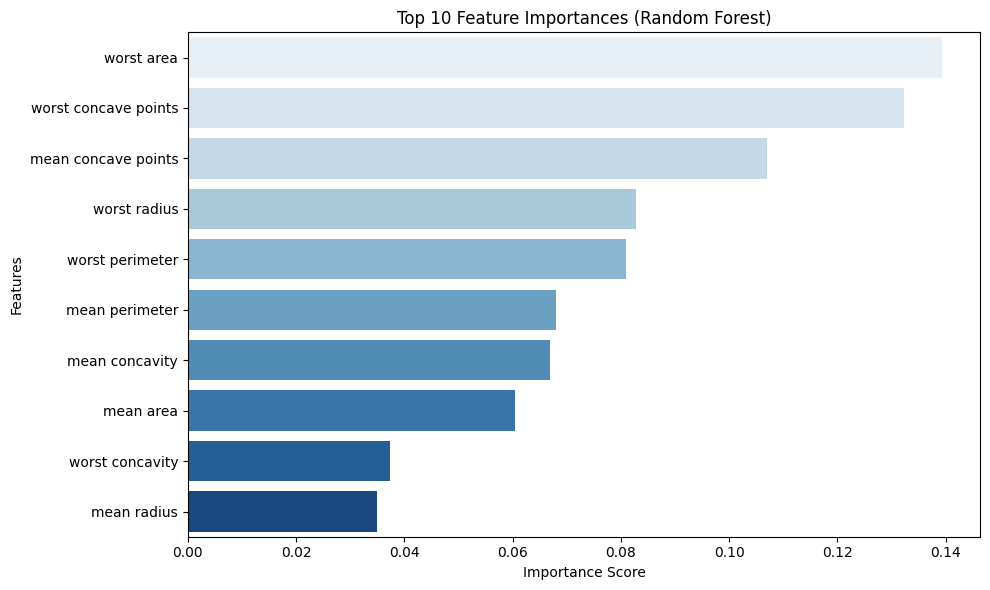

In [25]:
# M:1 Feature Selection using Random Forest
import matplotlib
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_scaled_df, y)
importances = pd.Series(rf.feature_importances_, index=x_scaled_df.columns)
importances_sorted = importances.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances_sorted[:10], y=importances_sorted.index[:10], palette='Blues')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()




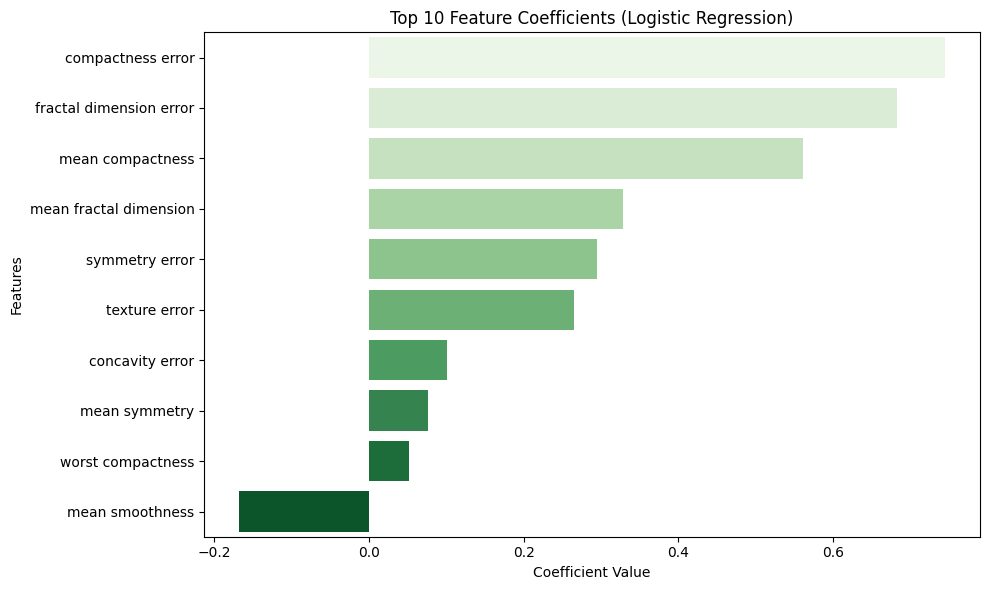

In [26]:
#M:2 coefficient based feature selection
logreg = LogisticRegression(max_iter=10000)
logreg.fit(x_scaled_df, y)
coefficients = pd.Series(logreg.coef_[0], index=x_scaled_df.columns)
coefficients_sorted = coefficients.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=coefficients_sorted[:10], y=coefficients_sorted.index[:10], palette='Greens')
plt.title('Top 10 Feature Coefficients (Logistic Regression)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

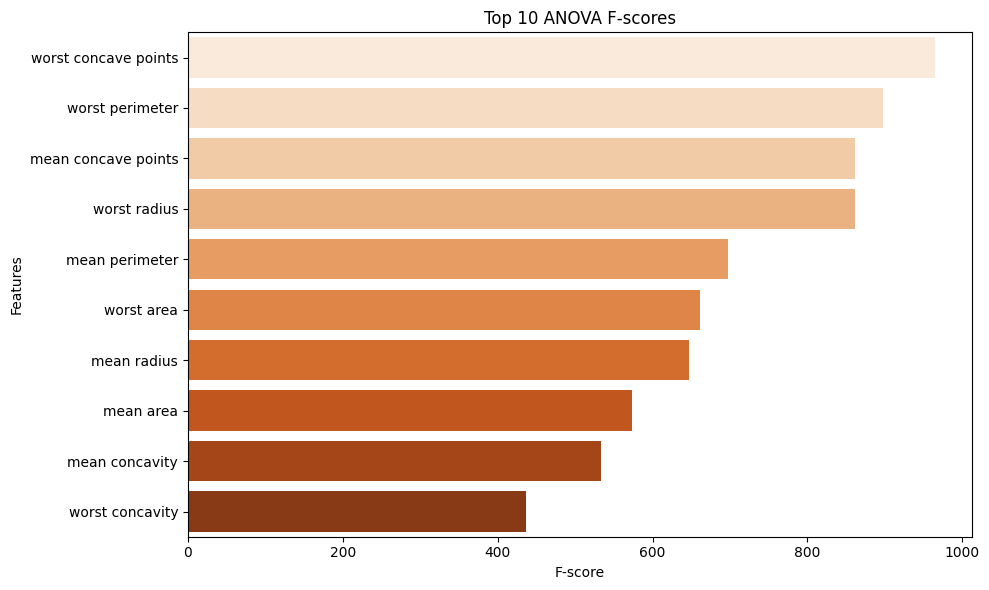

In [27]:
# M:3 ANOVA F - test scores (statistical Feature Selection)
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(x_scaled_df, y)
f_scores = pd.Series(selector.scores_, index=x_scaled_df.columns)
f_scores_sorted = f_scores.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=f_scores_sorted[:10], y=f_scores_sorted.index[:10], palette='Oranges')
plt.title('Top 10 ANOVA F-scores')
plt.xlabel('F-score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()